In [1]:
import numpy as np
import math
import matplotlib.pyplot as plt

In [2]:
x = np.linspace(-math.pi, math.pi, 2000)
x

array([-3.14159265, -3.13844949, -3.13530633, ...,  3.13530633,
        3.13844949,  3.14159265], shape=(2000,))

In [3]:
y = np.sin(x)
y

array([-1.22464680e-16, -3.14315906e-03, -6.28628707e-03, ...,
        6.28628707e-03,  3.14315906e-03,  1.22464680e-16], shape=(2000,))

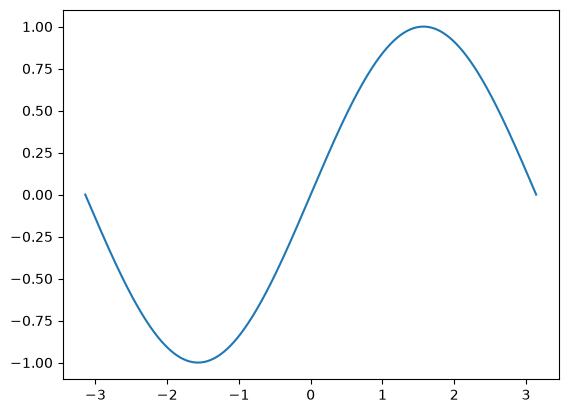

In [4]:
plt.plot(x, y)
plt.show()

In [5]:
a = np.random.randn()
b = np.random.randn()
c = np.random.randn()
d = np.random.randn()
a, b, c, d

(0.43827237770554595,
 -1.2884144037906888,
 -0.3408377194139826,
 -0.6538115393033359)

In [6]:
lr = 1e-6
lr

1e-06

In [7]:
loss_history = []
snapshots = {}
param_history = []
checkpoints = {0, 10, 50, 200, 700, 1999}

param_history.append((a, b, c, d))

for t in range(2000):
    y_pred = a + b * x + c * x ** 2 + d * x ** 3
    loss = np.square(y_pred - y).sum()

    loss_history.append(loss)
    
    if t%100 == 0:
        print(t, loss)
        
    if t in checkpoints:
        snapshots[t] = y_pred.copy()

    grad_y_pred = 2 * (y_pred - y)
    grad_a = grad_y_pred.sum()
    grad_b = (grad_y_pred * x).sum()
    grad_c = (grad_y_pred * x ** 2).sum()
    grad_d = (grad_y_pred * x ** 3).sum()
    
    a -= lr * grad_a
    b -= lr * grad_b
    c -= lr * grad_c
    d -= lr * grad_d

    param_history.append((a, b, c, d))

0 213697.65964857483
100 3011.6448127348176
200 2001.2441800806914
300 1331.1266938778601
400 886.6031821010995
500 591.6654192618327
600 395.93259237257445
700 266.0052075909127
800 179.73757194763385
900 122.44319101891791
1000 84.3804359383781
1100 59.08629482603393
1200 42.27198595739553
1300 31.09085628980924
1400 23.652987438171603
1500 18.703314657806146
1600 15.408136082803312
1700 13.213484158299021
1800 11.751149789868482
1900 10.776311563809404


In [8]:
print(f'Result: y = {a} + {b} x + {c} x^2 + {d} x^3')

Result: y = 0.015201883054065701 + 0.8243835518844203 x + -0.002622577787252234 x^2 + -0.08872784613868251 x^3


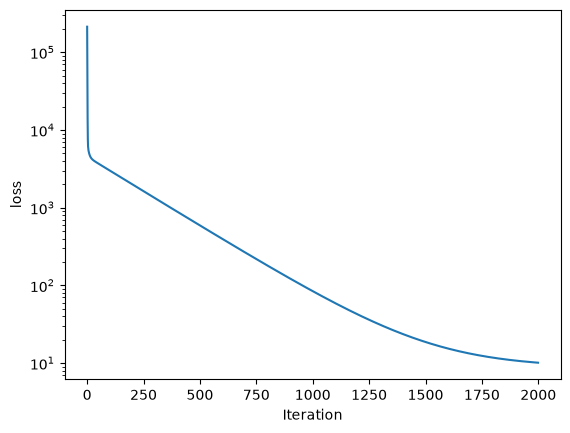

In [9]:
plt.plot(loss_history)
plt.xlabel("Iteration")
plt.ylabel("loss")
plt.yscale("log")
plt.show()

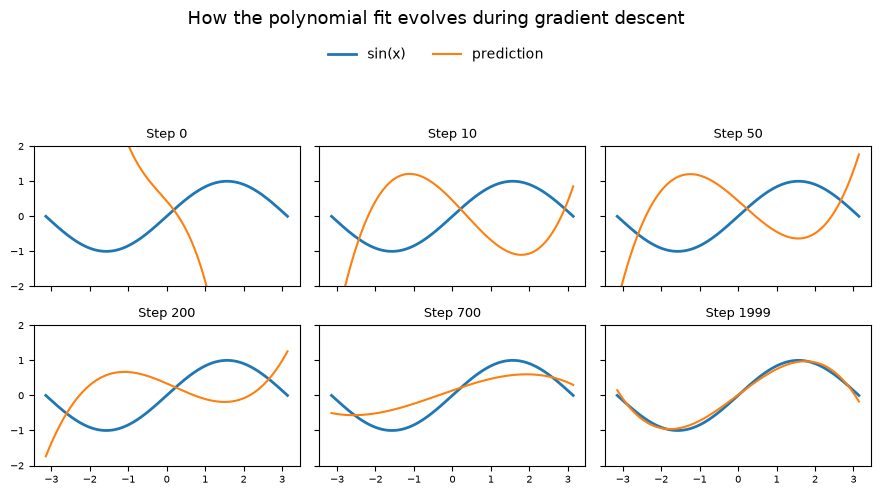

In [10]:
fig, axes = plt.subplots(
    2, 3,
    figsize=(9, 5),
    sharex=True,
    sharey=True
)

axes = axes.flatten()

for ax, (t, y_pred_snapshot) in zip(axes, snapshots.items()):
    ax.plot(x, y, label="sin(x)", linewidth=2)
    ax.plot(x, y_pred_snapshot, label="prediction")

    ax.set_title(f"Step {t}", fontsize=9)
    ax.set_ylim(-2, 2)
    ax.tick_params(labelsize=7)

# Main title
fig.suptitle(
    "How the polynomial fit evolves during gradient descent",
    fontsize=13,
    y=0.98
)

# Shared legend below title
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.93),
    ncol=2,
    frameon=False
)

# Leave space at top for title + legend
plt.tight_layout(rect=[0, 0, 1, 0.84])

plt.show()

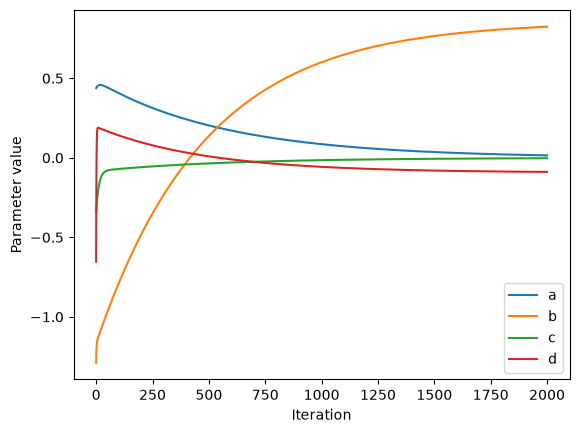

In [11]:
params = np.array(param_history)

plt.plot(params[:, 0], label="a")
plt.plot(params[:, 1], label="b")
plt.plot(params[:, 2], label="c")
plt.plot(params[:, 3], label="d")

plt.xlabel("Iteration")
plt.ylabel("Parameter value")
plt.legend()
plt.show()

In [12]:
b = 2.0
lr = 1e-5
tol = 1e-2

b_history = []

for t in range(100):
    y_pred = b * x
    loss = np.square(y_pred - y).sum()

    b_history.append(b)

    grad_y_pred = 2 * (y_pred - y)
    grad_b = (grad_y_pred * x).sum()

    # How far would the next update move b?
    step = lr * grad_b

    if abs(step) < tol:
        break

    b -= lr * grad_b

In [13]:
b_values = np.linspace(-2, 3, 300)

loss_values = []

for candidate_b in b_values:
    candidate_pred = candidate_b * x
    candidate_loss = np.square(candidate_pred - y).sum()
    loss_values.append(candidate_loss)

In [14]:
print("Iterations:", len(b_history))
print("Final b:", b)
print("Final step:", abs(lr * grad_b))

Iterations: 23
Final b: 0.3793649244291343
Final step: 0.009992403348742428


In [17]:
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

fig, ax = plt.subplots(figsize=(7, 4))

ax.plot(b_values, loss_values)

dot, = ax.plot([], [], "o", markersize=8)

ax.set_xlabel("b")
ax.set_ylabel("Loss")
ax.set_title("Gradient descent finding the minimum")

def update(frame):
    b = b_history[frame]

    y_pred = b * x
    loss = np.square(y_pred - y).sum()

    dot.set_data([b], [loss])

    return dot,

animation = FuncAnimation(
    fig,
    update,
    frames=len(b_history),
    interval=100,
    repeat=False
)

plt.close()

HTML(animation.to_jshtml())

In [24]:
import torch

In [25]:
device = torch.device("cpu")
dtype = torch.float

In [27]:
x = torch.linspace(-math.pi, math.pi, 2000, device=device, dtype=dtype)
y = torch.sin(x)
x, y

(tensor([-3.1416, -3.1384, -3.1353,  ...,  3.1353,  3.1384,  3.1416]),
 tensor([ 8.7423e-08, -3.1430e-03, -6.2863e-03,  ...,  6.2863e-03,
          3.1430e-03, -8.7423e-08]))

In [50]:
a = torch.randn((), device=device, dtype=dtype)
b = torch.randn((), device=device, dtype=dtype)
c = torch.randn((), device=device, dtype=dtype)
d = torch.randn((), device=device, dtype=dtype)
a, b, c, d

(tensor(-0.2917), tensor(0.3489), tensor(0.4687), tensor(-0.9027))

In [51]:
lr = 1e-6

for t in range(2000):
    y_pred = a + b * x + c * x ** 2 + d * x ** 3
    loss = (y_pred - y).pow(2).sum().item()

    if t%100 == 0:
        print(t, loss, a_grad, b_grad, c_grad, d_grad)

    y_pred_grad = 2 * (y_pred - y)
    a_grad = y_pred_grad.sum()
    b_grad = (x * y_pred_grad).sum()
    c_grad = (x ** 2 * y_pred_grad).sum()
    d_grad = (x ** 3 * y_pred_grad).sum()

    a -= lr * a_grad
    b -= lr * b_grad
    c -= lr * c_grad
    d -= lr * d_grad

0 221214.9375 tensor(nan) tensor(nan) tensor(nan) tensor(nan)
100 194.48545837402344 tensor(-525.3137) tensor(-648.0359) tensor(99.0389) tensor(92.1774)
200 135.41415405273438 tensor(-443.0907) tensor(-526.9659) tensor(76.4430) tensor(74.9556)
300 95.23555755615234 tensor(-372.7380) tensor(-428.5147) tensor(64.3033) tensor(60.9516)
400 67.8763427734375 tensor(-313.5555) tensor(-348.4568) tensor(54.0930) tensor(49.5649)
500 49.22515106201172 tensor(-263.7699) tensor(-283.3551) tensor(45.5044) tensor(40.3077)
600 36.49592971801758 tensor(-221.8891) tensor(-230.4167) tensor(38.2795) tensor(32.7775)
700 27.79831314086914 tensor(-186.6580) tensor(-187.3685) tensor(32.2018) tensor(26.6519)
800 21.848682403564453 tensor(-157.0209) tensor(-152.3626) tensor(27.0881) tensor(21.6749)
900 17.774105072021484 tensor(-132.0894) tensor(-123.8977) tensor(22.7877) tensor(17.6244)
1000 14.980400085449219 tensor(-111.1166) tensor(-100.7496) tensor(19.1688) tensor(14.3320)
1100 13.062780380249023 tensor(-9

In [52]:
print(f'Result: y = {a.item()} + {b.item()} x + {c.item()} x^2 + {d.item()} x^3')

Result: y = -0.01139505673199892 + 0.8505884408950806 x + 0.001965836388990283 x^2 + -0.09245526045560837 x^3


In [53]:
# try doing lr = 1e-5 and see what happens?

In [54]:
def train(lr):
    a = torch.randn(())
    b = torch.randn(())
    c = torch.randn(())
    d = torch.randn(())

    losses = []
    grad_norms = []

    for t in range(2000):
        y_pred = a + b*x + c*x**2 + d*x**3
        loss = (y_pred - y).pow(2).sum()

        y_pred_grad = 2 * (y_pred - y)

        a_grad = y_pred_grad.sum()
        b_grad = (y_pred_grad * x).sum()
        c_grad = (y_pred_grad * x**2).sum()
        d_grad = (y_pred_grad * x**3).sum()

        grad_norm = torch.sqrt(
            a_grad**2 +
            b_grad**2 +
            c_grad**2 +
            d_grad**2
        )

        if not torch.isfinite(loss) or not torch.isfinite(grad_norm):
            break

        losses.append(loss.item())
        grad_norms.append(grad_norm.item())

        a -= lr * a_grad
        b -= lr * b_grad
        c -= lr * c_grad
        d -= lr * d_grad

    return losses, grad_norms

In [55]:
good_loss, good_grad = train(1e-6)
bad_loss, bad_grad = train(1e-5)

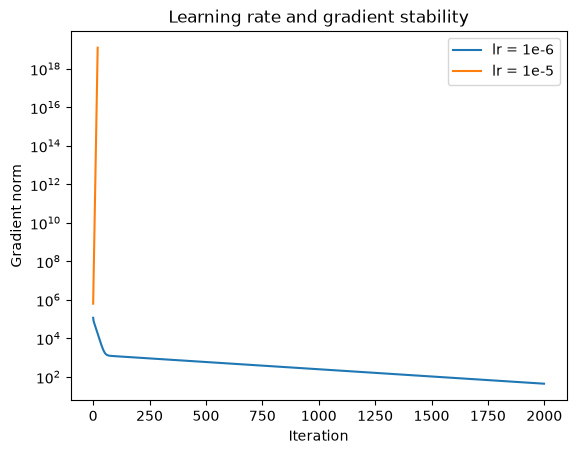

In [56]:
plt.plot(good_grad, label="lr = 1e-6")
plt.plot(bad_grad, label="lr = 1e-5")

plt.yscale("log")
plt.xlabel("Iteration")
plt.ylabel("Gradient norm")
plt.title("Learning rate and gradient stability")
plt.legend()

plt.show()

# Benchmarking

In [57]:
import time
import numpy as np
import torch

In [58]:
def train_numpy(x, y, steps=2000, lr=1e-6):
    a, b, c, d = [np.float32(v) for v in [0.5, -0.3, 0.2, 0.1]]

    for _ in range(steps):
        y_pred = a + b*x + c*x**2 + d*x**3

        grad_y_pred = 2 * (y_pred - y)

        grad_a = grad_y_pred.sum()
        grad_b = (grad_y_pred * x).sum()
        grad_c = (grad_y_pred * x**2).sum()
        grad_d = (grad_y_pred * x**3).sum()

        a -= lr * grad_a
        b -= lr * grad_b
        c -= lr * grad_c
        d -= lr * grad_d

In [80]:
def train_torch(x, y, steps=2000, lr=1e-6):
    device = x.device
    
    a, b, c, d = [torch.tensor(v, device=device) for v in [0.5, -0.3, 0.2, 0.1]]

    for _ in range(steps):
        y_pred = a + b*x + c*x**2 + d*x**3

        grad_y_pred = 2 * (y_pred - y)

        grad_a = grad_y_pred.sum()
        grad_b = (grad_y_pred * x).sum()
        grad_c = (grad_y_pred * x**2).sum()
        grad_d = (grad_y_pred * x**3).sum()

        a -= lr * grad_a
        b -= lr * grad_b
        c -= lr * grad_c
        d -= lr * grad_d

In [81]:
N = 2000

x_np = np.linspace(-np.pi, np.pi, N, dtype=np.float32)
y_np = np.sin(x_np)

x_torch = torch.from_numpy(x_np)
y_torch = torch.from_numpy(y_np)

x_cpu = x_torch
y_cpu = y_torch

x_mps = x_torch.to("mps")
y_mps = y_torch.to("mps")

In [85]:
def benchmark(fn, *args, repeats=5, mps=False):
    times = []

    for _ in range(repeats):
        if mps:
            torch.mps.synchronize()

        start = time.perf_counter()

        fn(*args)

        if mps:
            torch.mps.synchronize()

        times.append(time.perf_counter() - start)

    return np.mean(times), np.std(times)


np_mean, np_std = benchmark(train_numpy, x_np, y_np)
torch_cpu_mean, torch_cpu_std = benchmark(train_torch, x_torch, y_torch)
torch_mps_mean, torch_mps_std = benchmark(train_torch, x_mps, y_mps, mps=True)

print(f"NumPy:   {np_mean * 1000:.2f} ± {np_std * 1000:.2f} ms")
print(f"PyTorch: {torch_cpu_mean * 1000:.2f} ± {torch_cpu_std * 1000:.2f} ms")
print(f"PyTorch MPS: {torch_mps_mean * 1000:.2f} ± {torch_mps_std * 1000:.2f} ms")

NumPy:   74.36 ± 6.58 ms
PyTorch: 71.53 ± 0.16 ms
PyTorch MPS: 318.15 ± 1.82 ms


In [86]:
sizes = [2_000, 20_000, 200_000]

results = {
    "numpy": [],
    "torch_cpu": [],
    "torch_mps": [],
}

for n in sizes:
    print(f"\nN = {n:,}")

    # Same float32 data for everyone
    x_np = np.linspace(-np.pi, np.pi, n, dtype=np.float32)
    y_np = np.sin(x_np)

    x_cpu = torch.from_numpy(x_np)
    y_cpu = torch.from_numpy(y_np)

    x_mps = x_cpu.to("mps")
    y_mps = y_cpu.to("mps")

    # Warm up MPS
    train_torch(x_mps, y_mps, steps=10)
    torch.mps.synchronize()

    np_mean, np_std = benchmark(
        train_numpy, x_np, y_np
    )

    cpu_mean, cpu_std = benchmark(
        train_torch, x_cpu, y_cpu
    )

    mps_mean, mps_std = benchmark(
        train_torch, x_mps, y_mps,
        mps=True
    )

    results["numpy"].append(np_mean)
    results["torch_cpu"].append(cpu_mean)
    results["torch_mps"].append(mps_mean)

    print(f"NumPy:       {np_mean * 1000:8.2f} ± {np_std * 1000:.2f} ms")
    print(f"PyTorch CPU: {cpu_mean * 1000:8.2f} ± {cpu_std * 1000:.2f} ms")
    print(f"PyTorch MPS: {mps_mean * 1000:8.2f} ± {mps_std * 1000:.2f} ms")


N = 2,000
NumPy:          97.70 ± 35.48 ms
PyTorch CPU:    71.95 ± 0.33 ms
PyTorch MPS:   318.61 ± 2.11 ms

N = 20,000


/Users/saheb/home/playground/.venv/lib/python3.11/site-packages/numpy/_core/_methods.py:49: RuntimeWarning: overflow encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)
/Users/saheb/home/playground/.venv/lib/python3.11/site-packages/numpy/_core/_methods.py:49: RuntimeWarning: invalid value encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)
/var/folders/cs/t93wqfqx0b347lj6vslh61_w0000gn/T/ipykernel_23999/1854901465.py:17: RuntimeWarning: invalid value encountered in scalar subtract
  d -= lr * grad_d


NumPy:         547.38 ± 1.03 ms
PyTorch CPU:   182.27 ± 0.32 ms
PyTorch MPS:   345.80 ± 2.17 ms

N = 200,000
NumPy:        5205.06 ± 13.57 ms
PyTorch CPU:  1528.32 ± 762.34 ms
PyTorch MPS:   635.94 ± 104.19 ms

N = 2,000,000
NumPy:       54298.97 ± 592.53 ms
PyTorch CPU: 11883.16 ± 1645.39 ms
PyTorch MPS: 11706.99 ± 170.13 ms


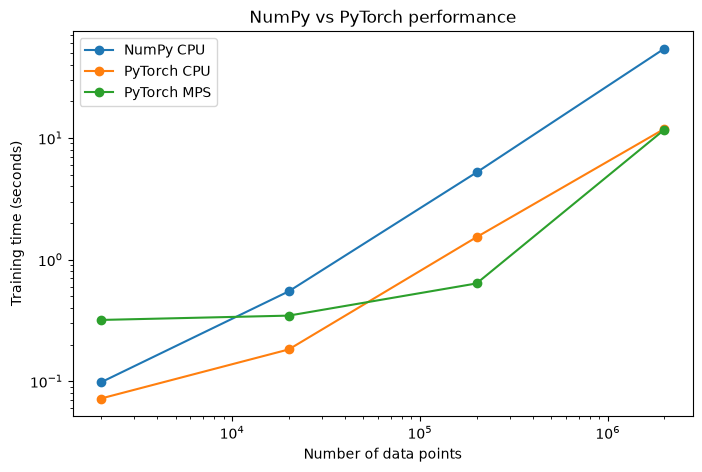

In [87]:
plt.figure(figsize=(8, 5))

plt.plot(sizes, results["numpy"], marker="o", label="NumPy CPU")
plt.plot(sizes, results["torch_cpu"], marker="o", label="PyTorch CPU")
plt.plot(sizes, results["torch_mps"], marker="o", label="PyTorch MPS")

plt.xscale("log")
plt.yscale("log")

plt.xlabel("Number of data points")
plt.ylabel("Training time (seconds)")
plt.title("NumPy vs PyTorch performance")
plt.legend()

plt.show()